# EDA

In [1]:
import os, pickle, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

## 01 Import data

In [2]:
DATA_DIR = "data"
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
VALID_CSV = os.path.join(DATA_DIR, "valid.csv")
TEST_CSV  = os.path.join(DATA_DIR, "test.csv")
EHR_PICKLE = os.path.join(DATA_DIR, "ehr_preprocessed_seq_by_day_cat_embedding.pkl")

LABEL_COL = "readmitted_within_30days"

train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)
test_df  = pd.read_csv(TEST_CSV)

with open(EHR_PICKLE, "rb") as f:
    ehr = pickle.load(f)

# Retain 1 row for each unqiue id
train_id = train_df["id"].drop_duplicates().tolist()
valid_id = valid_df["id"].drop_duplicates().tolist()
test_id  = test_df["id"].drop_duplicates().tolist()

feat_dict = ehr["feat_dict"]

feature_cols = ehr["feature_cols"]
demo_cols = ehr["demo_cols"] # 3: 0, 1, 2
icd_cols  = ehr["icd_cols"]  # 91: 3, ..., 93
lab_cols  = ehr["lab_cols"]  # 36: 94, ..., 129
med_cols  = ehr["med_cols"]  # 41: 130, ..., 170
cat_idxs  = ehr["cat_idxs"]
cat_dims  = ehr["cat_dims"]

In [3]:
N_FEAT = 171

# Location of each feature group
DEMO = slice(0, 3)
ICD  = slice(3, 94)
LAB  = slice(94, 130)
MED  = slice(130, 171)

In [4]:
# number of rows in each csv
print("train rows:", len(train_df), "\nvalid rows:", len(valid_df), "\ntest rows:", len(test_df))

train rows: 49451 
valid rows: 16721 
test rows: 16293


In [5]:
# use binary labels
train_df[LABEL_COL] = train_df[LABEL_COL].map(lambda i: 1 if i else 0).astype(int)
valid_df[LABEL_COL] = valid_df[LABEL_COL].map(lambda i: 1 if i else 0).astype(int)
print("train positive rate:", round(train_df.drop_duplicates('id')[LABEL_COL].mean(),4))
print("valid positive rate:", round(valid_df.drop_duplicates('id')[LABEL_COL].mean(),4))

train positive rate: 0.176
valid positive rate: 0.1725


Around avg 17.5% positive rate indicate **class imbalance** problem.

In [6]:
combined_df = pd.concat([train_df, valid_df], ignore_index=True).drop_duplicates("id").copy()
combined_df["subject_id"] = combined_df["id"].str.split("_").str[0]  # id format: patient_admission
combined_df["split"] = np.where(combined_df["id"].isin(set(train_id)), "train", "valid")
admissions = combined_df[["id", "subject_id", "split", LABEL_COL]].reset_index(drop=True)

print("labeled admissions:", len(admissions))
print("unique patients   :", admissions["subject_id"].nunique())
admissions.head()

labeled admissions: 11022
unique patients   : 8833


,id,subject_id,split,readmitted_within_30days
0,10869829_25238191,10869829,train,0
1,12347278_29852086,12347278,train,0
2,11157850_29572307,11157850,train,1
3,11958726_24320913,11958726,train,0
4,11944377_26689168,11944377,train,0


## 02 Integrity check

In [7]:
# check every admission has mathcing feature data
fd_keys = set(feat_dict.keys())
for name, ids in [("train", train_id), ("valid", valid_id), ("test", test_id)]:
    missing = set(ids) - fd_keys
    print(f"{name:5s}: {len(ids):5d} admissions | missing feature data: {len(missing)}")

# ensuring an id does not appear in different splits
print("\nsame id in two splits? (all should be 0)")
print("  train & valid:", len(set(train_id) & set(valid_id)))
print("  train & test :", len(set(train_id) & set(test_id)))
print("  valid & test :", len(set(valid_id) & set(test_id)))

# check every admission table is 171 columns wide
widths = {feat_dict[i].shape[1] for i in (train_id + valid_id)}
print("\nall admission tables are 171 columns wide:", widths == {171})

train:  8234 admissions | missing feature data: 0
valid:  2788 admissions | missing feature data: 0
test :  2741 admissions | missing feature data: 0

same id in two splits? (all should be 0)
  train & valid: 0
  train & test : 0
  valid & test : 0

all admission tables are 171 columns wide: True


## 03 How often patients readmitted?

In [8]:
admissions_per_patient = admissions.groupby("subject_id").size()

repeat_patients = int((admissions_per_patient > 1).sum())
repeat_admissions = int(admissions_per_patient[admissions_per_patient > 1].sum())
print("patients with more than one admission:", repeat_patients)
print("admissions those patients account for:", repeat_admissions,
      f"({repeat_admissions/len(admissions):.0%} of all admissions)")

print("\nhow many admissions patients have:")
print(admissions_per_patient.value_counts().sort_index().rename("num_patients").to_frame().head(10))

patients with more than one admission: 1529
admissions those patients account for: 3718 (34% of all admissions)

how many admissions patients have:
    num_patients
1           7304
2           1111
3            271
4             89
5             40
6              8
7              5
8              3
10             2


## 04 How long are the hospital stays?

length of stay (days):
  shortest: 3  median: 11  typical-long (95th pct): 37  longest: 231


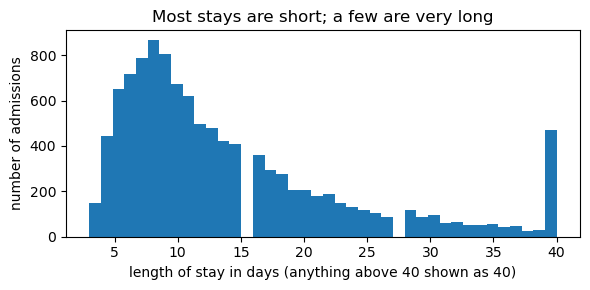

In [9]:
# Each admission's feature table has one row per DAY of that single hospital
# stay (verified in the next cell). So the number of rows = length of stay.
# NOTE: these rows are the day-by-day timeline WITHIN one admission; they are
# not separate visits and not a count of readmissions.
n_days = np.array([feat_dict[i].shape[0] for i in admissions["id"]])
print("length of stay (days):")
print("  shortest:", n_days.min(), " median:", int(np.median(n_days)),
      " typical-long (95th pct):", int(np.percentile(n_days, 95)),
      " longest:", n_days.max())

plt.figure(figsize=(6, 3))
plt.hist(np.clip(n_days, 0, 40), bins=40)
plt.xlabel("length of stay in days (anything above 40 shown as 40)")
plt.ylabel("number of admissions")
plt.title("Most stays are short; a few are very long")
plt.tight_layout(); plt.show()

**Quick check — what is a "row"?** Before trusting that one row = one day of a single stay, we verify it. If rows are consecutive days of the *same* admission, then a value that can't change within a stay — like age — should be identical on every row. We also sanity-check the row count: 231 rows is believable as the length of one very long stay, but absurd as 231 separate visits inside a single admission id.

In [10]:
# pick one admission and inspect its rows
sample_id = admissions["id"].iloc[0]
m = feat_dict[sample_id]
print("admission:", sample_id, "-> shape:", m.shape, "(rows, features)")
print("age on each row (constant => rows are days of ONE stay):")
print(m[:, 0])   # column 0 = age
print("age is constant across rows:", bool((m[:, 0] == m[0, 0]).all()))

admission: 10869829_25238191 -> shape: (13, 171) (rows, features)
age on each row (constant => rows are days of ONE stay):
[52 52 52 52 52 52 52 52 52 52 52 52 52]
age is constant across rows: True


## 05 Which parts of the data change day-to-day within an admission?

In [11]:
groups = {"demo": DEMO, "icd": ICD, "lab": LAB, "med": MED}
varying_counts = {g: [] for g in groups}

for i in admissions["id"]:
    m = feat_dict[i]
    changes = (m.max(0) != m.min(0))              # True where a column changes across rows
    for g, sl in groups.items():                  # sl is a slice object (e.g. slice(0,3))
        varying_counts[g].append(int(changes[sl].sum()))   # index directly with the slice

print("average number of columns that CHANGE within an admission, by group:")
for g in groups:
    width = groups[g].stop - groups[g].start
    print(f"  {g:5s}: {np.mean(varying_counts[g]):.2f}  (out of {width} columns)")

average number of columns that CHANGE within an admission, by group:
  demo : 0.00  (out of 3 columns)
  icd  : 0.00  (out of 91 columns)
  lab  : 11.30  (out of 36 columns)
  med  : 0.00  (out of 41 columns)


## 06 Among repeat patients, are those who were readmitted once more likely to be readmitted again?

In [12]:
overall = admissions[LABEL_COL].mean()
repeats = admissions.groupby("subject_id").filter(lambda g: len(g) > 1)
print("\nreadmission rate among repeat-patient admissions:", round(repeats[LABEL_COL].mean(), 4),"vs overall", round(overall, 4))


readmission rate among repeat-patient admissions: 0.2754 vs overall 0.1751


## 07 Readmission by Age

In [13]:
demo_vals = np.array([feat_dict[i][0, 0:3] for i in admissions["id"]])
demo = pd.DataFrame(demo_vals, columns=["age", "sex", "ethnicity"])
demo[LABEL_COL] = admissions[LABEL_COL].values

print("age range:", demo["age"].min(), "to", demo["age"].max())

# readmission rate by age group
age_band = pd.cut(demo["age"], [0, 40, 55, 65, 75, 85, 200])
print("\nreadmission rate by age group:")
print(demo.groupby(age_band)[LABEL_COL].agg(rate="mean", admissions="size").round(3))

age range: 18 to 99

readmission rate by age group:
            rate  admissions
age                         
(0, 40]    0.102         864
(40, 55]   0.163        1697
(55, 65]   0.160        2362
(65, 75]   0.179        2673
(75, 85]   0.202        2194
(85, 200]  0.217        1232


## 08 Readmission by Gender

In [14]:
# 'sex' is column 1 of demographics (a 0/1 code). Show readmission rate per
# value and how many admissions fall in each group.
print("readmission rate by sex code:")
print(demo.groupby("sex")[LABEL_COL].agg(rate="mean", admissions="size").round(3))

readmission rate by sex code:
      rate  admissions
sex                   
0    0.167        4963
1    0.182        6059


## 09 Readmission by Ethnics

In [15]:
# 'ethnicity' is column 2 of demographics (a small integer category code,
# 7 possible values). The codes are anonymized so we cannot name the groups,
# but we can still see whether readmission rate differs across them.
# Watch the admissions count: groups with few admissions have noisy rates.
print("readmission rate by ethnicity code:")
print(demo.groupby("ethnicity")[LABEL_COL]
          .agg(rate="mean", admissions="size")
          .sort_values("rate", ascending=False).round(3))

readmission rate by ethnicity code:
            rate  admissions
ethnicity                   
5          0.251         709
1          0.202         336
0          0.190          42
2          0.183        1342
4          0.178         512
6          0.168        7643
3          0.123         438


## 10 Readmission by ICDs

In [16]:
# for each admission, did each ICD group appear on any day?  (present = 1)
icd_present = np.array([(feat_dict[i][:, 3:94].max(0) > 0).astype(int) for i in admissions["id"]])
icd = pd.DataFrame(icd_present, columns=icd_cols)
y = admissions[LABEL_COL].values

# how common is each diagnosis group?
prevalence = icd.mean().sort_values(ascending=False)
print("most common diagnosis groups (share of admissions):")
print(prevalence.head(8).round(3))

# which diagnoses go with the biggest jump in readmission rate?
base = y.mean()
rows = []
for c in icd_cols:
    mask = icd[c] > 0
    if mask.sum() >= 30:                       # ignore very rare ones
        rows.append((c, mask.mean(), y[mask].mean(), y[~mask].mean()))
lift = pd.DataFrame(rows, columns=["icd", "how_common", "rate_if_present", "rate_if_absent"])
lift["difference"] = (lift["rate_if_present"] - lift["rate_if_absent"]).round(3)
print("\ndiagnoses linked to the biggest rise in readmission:")
print(lift.sort_values("difference", ascending=False).head(8).round(3).to_string(index=False))

most common diagnosis groups (share of admissions):
I10-I16    0.116
D60-D64    0.051
E40-E46    0.035
J90-J94    0.028
G89-G99    0.028
R00-R09    0.023
I80-I89    0.015
A30-A49    0.014
dtype: float64

diagnoses linked to the biggest rise in readmission:
    icd  how_common  rate_if_present  rate_if_absent  difference
J80-J84       0.004            0.350           0.174       0.176
R30-R39       0.008            0.290           0.174       0.116
R50-R69       0.014            0.240           0.174       0.066
A30-A49       0.014            0.233           0.174       0.058
E40-E46       0.035            0.231           0.173       0.058
I70-I79       0.004            0.224           0.175       0.050
I80-I89       0.015            0.222           0.174       0.048
R40-R46       0.008            0.220           0.175       0.045


## 11 Readmission by LABs

In [17]:
# NOTE on the earlier ">0 ever recorded" idea: it was misleading here. The
# body-fluid labs read as present for ~everyone (they are never truly zero in
# the encoding), so that question told us nothing. A more useful exploration
# question is: which labs actually VARY across admissions? A lab that is the
# same value for nearly everyone carries no signal; a lab that differs between
# admissions is where potential predictive signal lives.
#
# "share of admissions" below = the fraction of admissions (0..1) whose
# last-day value for that lab is non-zero. 1.0 means all admissions; 0.83
# means 83% of them.
lab_last = np.array([feat_dict[i][-1, 94:130] for i in admissions["id"]])  # last-day value
lab = pd.DataFrame(lab_last, columns=lab_cols)

nonzero_share = (lab != 0).mean().sort_values(ascending=False)
print("labs that vary most across admissions (share of admissions non-zero):")
print(nonzero_share.head(8).round(3))
print("\nlabs that are almost always the same value (little to no signal):")
print(nonzero_share.tail(8).round(3))

labs that vary most across admissions (share of admissions non-zero):
Basophils Other Body Fluid    1.0
Basophils Joint Fluid         1.0
Eosinophils Joint Fluid       1.0
Basophils Pleural             1.0
Basophils Ascites             1.0
Lymphocytes Joint Fluid       1.0
H Blood                       1.0
pH Urine                      1.0
dtype: float64

labs that are almost always the same value (little to no signal):
Bicarbonate Blood       0.870
Chloride Blood          0.851
Calcium, Total Blood    0.824
Platelet Count Blood    0.776
Creatinine Blood        0.746
Glucose Blood           0.582
Hematocrit Blood        0.405
Hemoglobin Blood        0.398
dtype: float64


## 12 Readmission by MEDs

In [18]:
# for each admission, was each drug class ever given?
med_any = np.array([(feat_dict[i][:, 130:171].max(0) > 0).astype(int) for i in admissions["id"]])
med = pd.DataFrame(med_any, columns=med_cols)

print("most commonly given drug classes (share of admissions):")
print(med.mean().sort_values(ascending=False).head(6).round(3))

# number of different drug classes per admission, vs readmission
num_classes = med.sum(axis=1)
band = pd.qcut(num_classes, 5)
tab = pd.DataFrame({"num_drug_classes_band": band, "y": admissions[LABEL_COL].values})
print("\nreadmission rate by how many different drug classes were given:")
print(tab.groupby("num_drug_classes_band")["y"].agg(rate="mean", admissions="size").round(3))

most commonly given drug classes (share of admissions):
ELECT/CALORIC/H2O    0.981
GASTROINTESTINAL     0.876
ANALGESICS           0.848
ANTIBIOTICS          0.794
ANTICOAGULANTS       0.632
DIURETICS            0.587
dtype: float64

readmission rate by how many different drug classes were given:
                        rate  admissions
num_drug_classes_band                   
(-0.001, 7.0]          0.108        2620
(7.0, 9.0]             0.145        2147
(9.0, 11.0]            0.179        2336
(11.0, 13.0]           0.208        1861
(13.0, 29.0]           0.258        2058


## 13 Per-Block Sparsity

In [19]:
# Per-block sparsity summary.
# For each admission we collapse its day-by-day table to one row per feature by
# taking the max over days (i.e. "did this feature ever appear during the stay").
# Then, per feature block, we report:
#   - zero_fraction : share of all entries that are 0 (higher = sparser/emptier)
#   - all_zero_cols : columns that are 0 for EVERY admission (never used -> drop)
#   - constant_cols : columns with the same value for every admission (no signal)
# Note: sparsity here is CROSS-ADMISSION (how often a feature shows up across
# patients), which is what matters for telling patients apart. It is not about
# day-to-day change within a stay (that was Section 05).

blocks = {"demo": DEMO, "icd": ICD, "lab": LAB, "med": MED}

# collapse every admission to one row of 171 features (max over its days)
collapsed = np.array([feat_dict[i].max(0) for i in admissions["id"]])  # shape (n_admissions, 171)

print(f"{'block':5s} | {'zero_fraction':>13s} | {'all_zero_cols':>13s} | {'constant_cols':>13s}")
print("-" * 56)
for name, sl in blocks.items():
    sub = collapsed[:, sl]                       # this block, all admissions
    zero_fraction = (sub == 0).mean()            # fraction of entries equal to 0
    all_zero_cols = int((sub == 0).all(axis=0).sum())        # columns that are always 0
    constant_cols = int((sub.max(0) == sub.min(0)).sum())    # columns with no variation
    width = sl.stop - sl.start
    print(f"{name:5s} | {zero_fraction:13.3f} | {all_zero_cols:>7d}/{width:<5d} | {constant_cols:>7d}/{width:<5d}")

block | zero_fraction | all_zero_cols | constant_cols
--------------------------------------------------------
demo  |         0.151 |       0/3     |       0/3    
icd   |         0.995 |       5/91    |       5/91   
lab   |         0.016 |       0/36    |      16/36   
med   |         0.749 |       1/41    |       1/41   
